# 1.환경 준비

- 데이터 : 임의로 만든 데이터
- Linear Regression, Ridge, Lasso, Elasticnet 알고리즘으로 모델링한다.

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

# 2.데이터 이해

# 3.데이터 준비

**1) x, y 분리**

In [2]:
from sklearn.datasets import make_regression

X, y, c = make_regression(n_samples=500, # 500개 행 생성
                          n_features=200, # 특성(피처) 개수 : 200개 열 생성
                          n_informative=15, # 실제 y에 영향을 주는 중요한 특성은 15개
                          bias=1,
                          noise=60,
                          coef=True,
                          random_state=1)



**2) 학습용, 평가용 데이터 분리**

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=1)

**3) 정규화**

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# 4.모델링

## 4.1.Linear Regression

- 우선 Linear Regression 알고리즘으로 모델링한다.

$$ \large cost=\sum_{i=1}^{n}(y_i-\hat y)^2 $$

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print('학습 성능:', model.score(X_train, y_train))
print('평가 성능:', model.score(X_test, y_test))

학습 성능: 0.9803903050465909
평가 성능: 0.8476766578971906


- 변수들의 가중치를 확인해 보면 모든 변수의 가중치가 존재함을 알 수 있다.

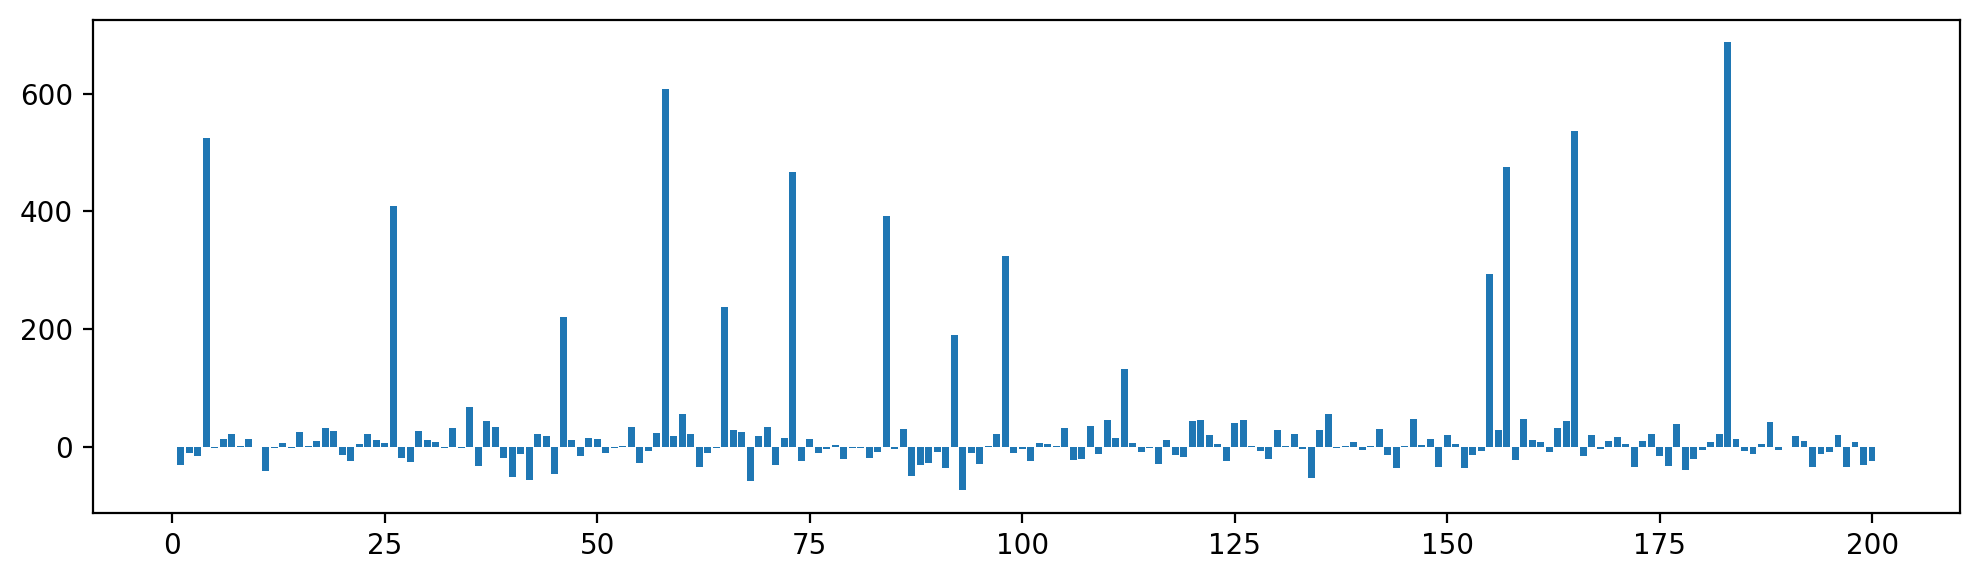

In [8]:
plt.figure(figsize=(10,3))
plt.bar(x=range(1, 201), height=model.coef_)
plt.tight_layout()
plt.show()

## 4.2.Ridge

- Ridge 알고리즘을 사용하면 변수들의 가중치 크기를 제어할 수 있다.
- 그렇다고 특정 변수의 가중치를 0으로 바꾸지는 않는다.

$$ \large cost=\sum_{i=1}^{n}(y_i-\hat y)^2+\lambda\sum_{j=1}^{p}(w_j)^2 $$

In [10]:
from sklearn.linear_model import Ridge

model_rg = Ridge(alpha=1) # 높일 수록 규제 강하게.

model_rg.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [12]:
print('학습 성능:', model_rg.score(X_train, y_train))
print('평가 성능:', model_rg.score(X_test, y_test))

학습 성능: 0.9676439399160339
평가 성능: 0.8341087672207208


- alpha 값을 변화시키면서 가중치 정보를 수집한다.

In [13]:
# 가중치 정보 수집
result = []
alpha = [0.1, 1, 10, 100, 1000, 5000]
for a in alpha:
    model_rg = Ridge(alpha=a)
    model_rg.fit(X_train, y_train)
    result.append(model_rg.coef_)


# 데이터 프레임 만들기
df_coef = pd.DataFrame(result, index=alpha)

df_coef




,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0.1,-32.017993,-13.807944,-15.814406,515.241531,3.899428,15.476797,20.290523,1.507378,11.600144,1.778425,...,20.642808,4.250566,-45.935025,-11.514860,-8.078955,18.755134,-33.800192,6.515168,-27.126092,-21.402473
1.0,-39.864362,-29.349600,-17.894648,453.902304,25.287754,26.430064,16.560836,-1.642499,0.189121,10.959186,...,28.608520,-19.428126,-98.428373,-10.166057,-10.901761,9.908179,-28.687540,1.659124,-10.240532,-8.851166
10.0,-35.785263,-40.678764,-15.671296,259.847047,16.229359,33.724580,19.472009,-13.028608,-12.717652,16.140204,...,36.789600,-17.121742,-106.814417,-10.579004,-18.605047,-11.414135,-7.155676,2.576308,8.348828,6.711369
100.0,-7.862032,-12.661016,-3.903064,58.548199,0.798163,9.869223,6.258622,-5.003234,-5.141164,2.466612,...,11.287232,-0.962739,-27.853770,-5.623148,-6.209389,-5.063289,2.352051,2.695453,2.591473,3.394558
1000.0,-0.869175,-1.567067,-0.472939,6.825223,-0.000642,1.192879,0.772269,-0.627590,-0.663531,0.226366,...,1.375257,-0.007742,-3.308630,-0.773973,-0.774580,-0.629845,0.402794,0.398667,0.294388,0.445944
5000.0,-0.175326,-0.320137,-0.096491,1.386007,-0.002150,0.243051,0.157686,-0.128342,-0.136123,0.044650,...,0.280448,0.000670,-0.673085,-0.159778,-0.158357,-0.128599,0.084553,0.082826,0.059508,0.091616


- alpha 값 변화에 따른 변수들 가중치 변화를 시각화로 확인한다.

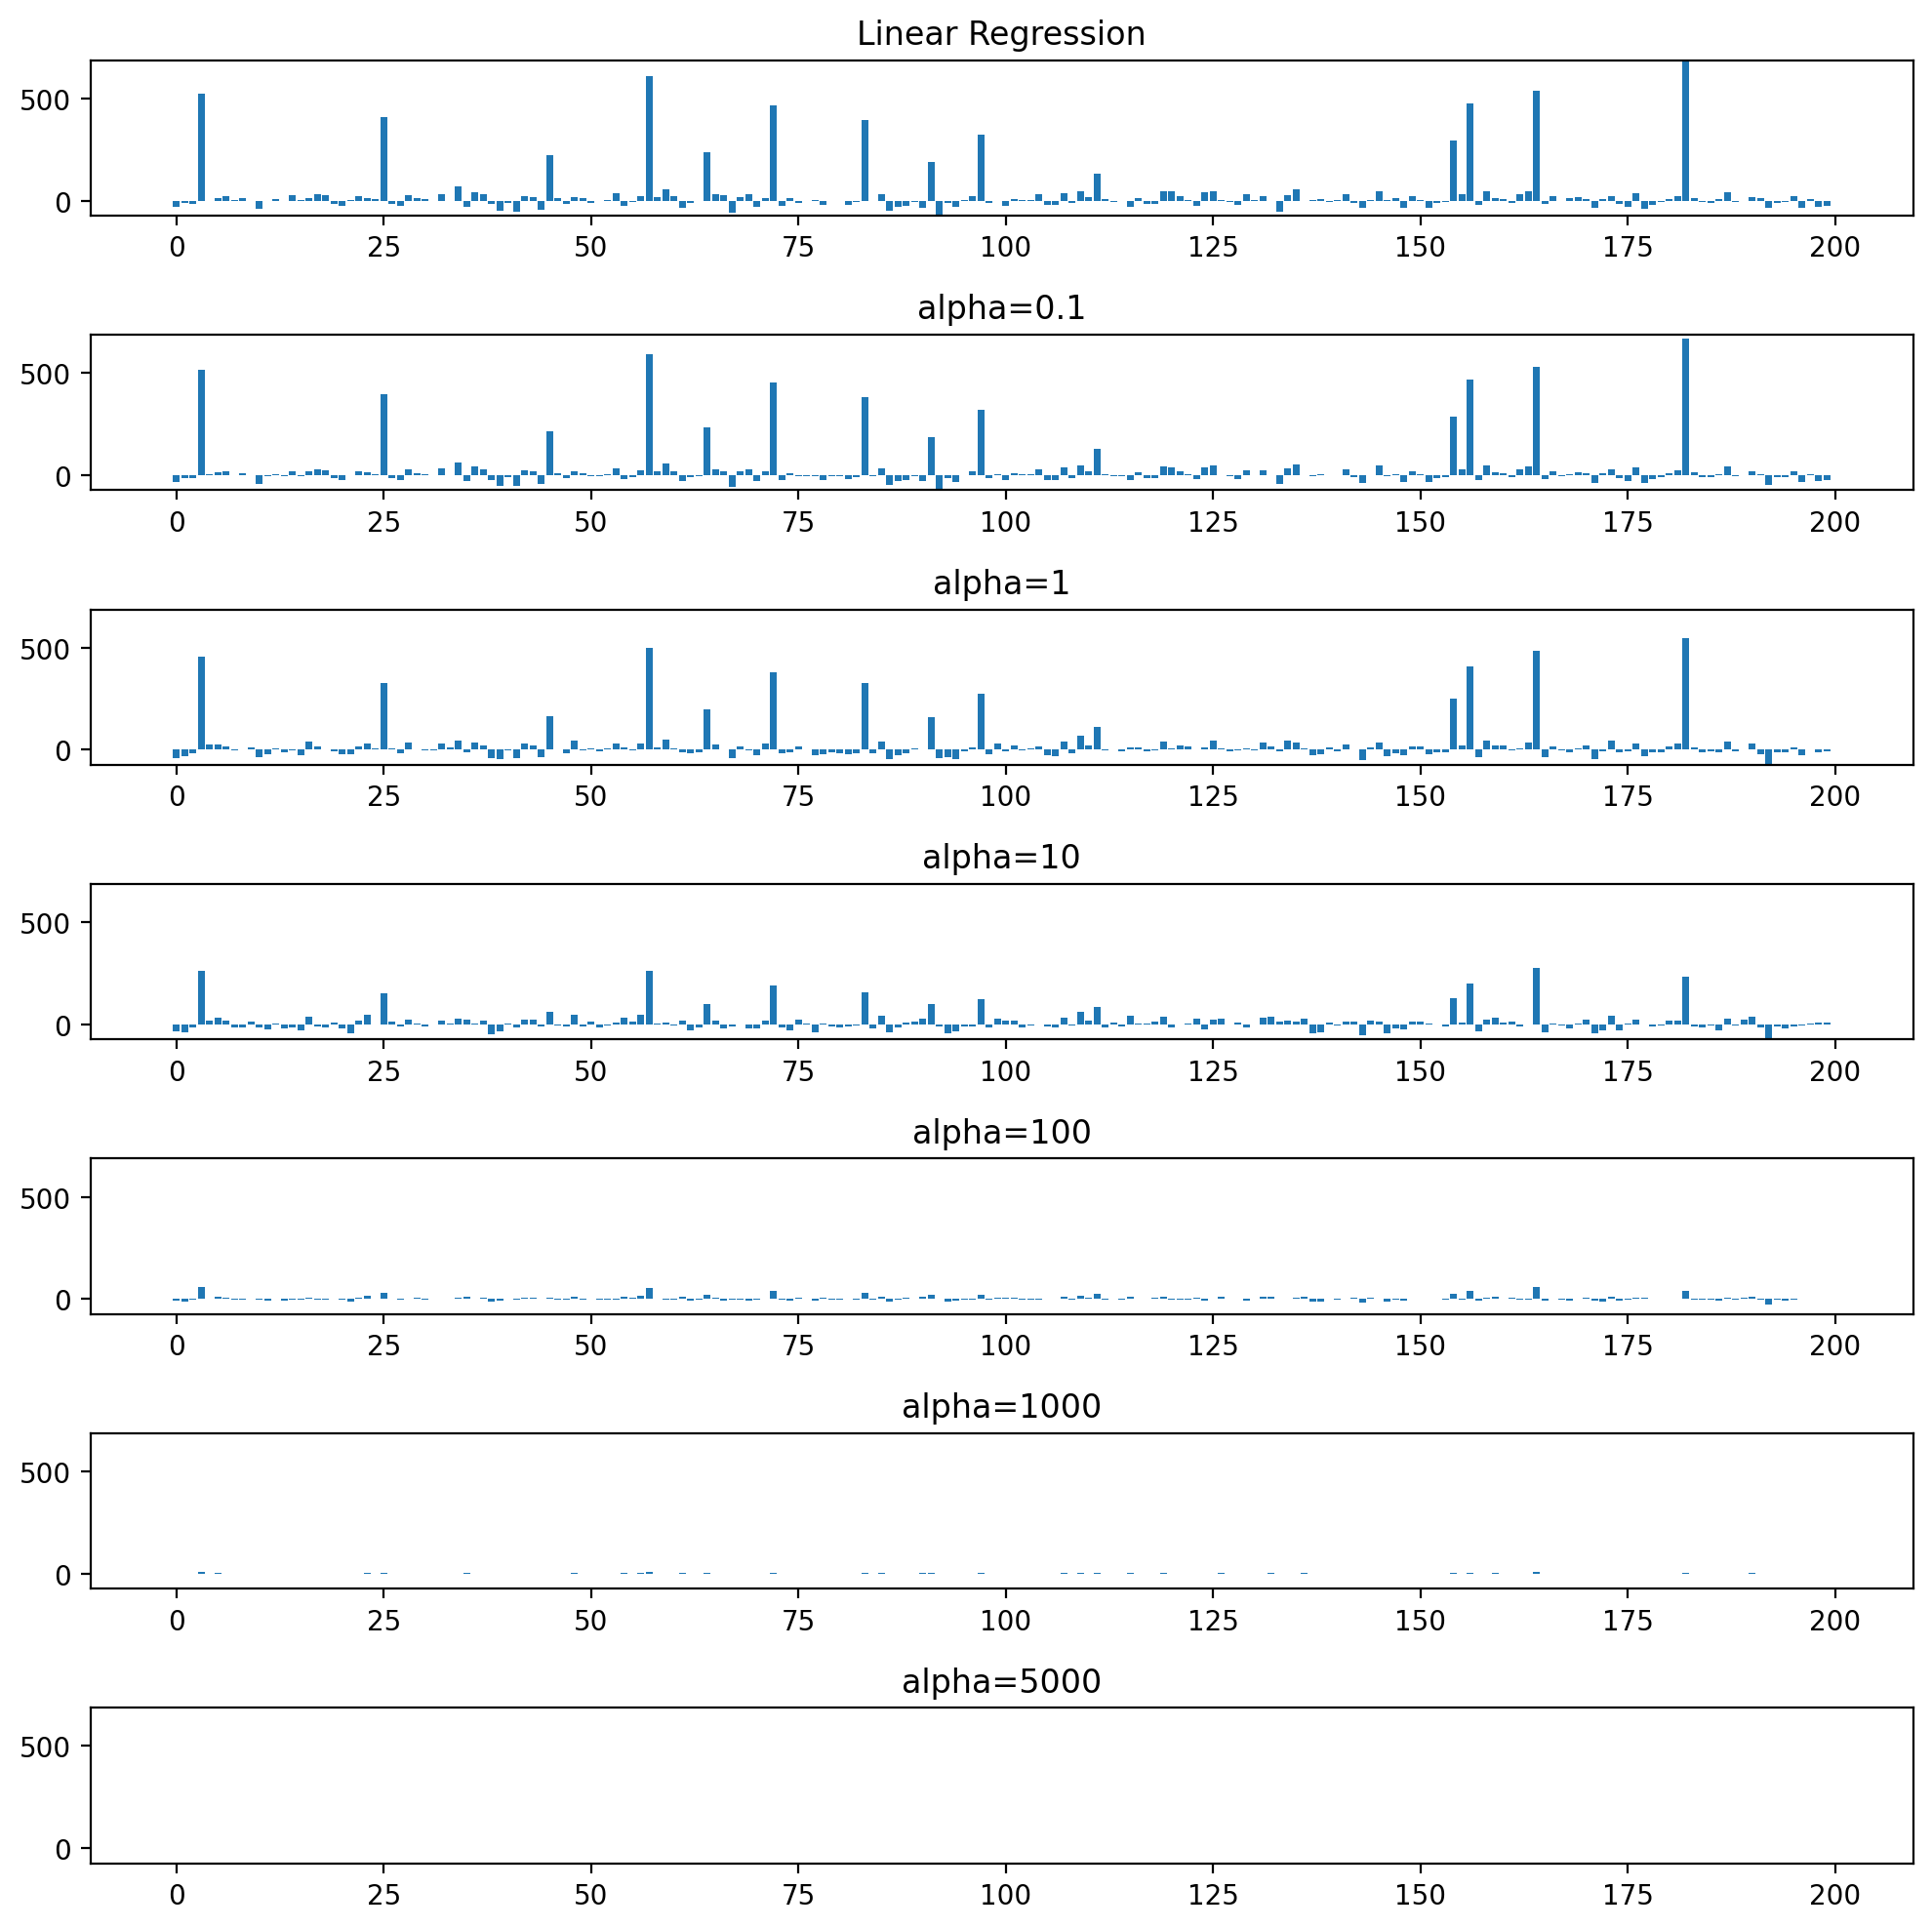

In [ ]:
# y축 최솟값, 최댓값
y_min = model.coef_.min()
y_max = model.coef_.max()
alpha = [0.1, 1, 10, 100, 1000, 5000]

# 회귀 계수 변화 시각화
plt.figure(figsize=(10,10))
plt.subplot(7,1,1)
plt.title('Linear Regression')
plt.bar(x=range(0, 200), height=model.coef_)
plt.ylim(y_min, y_max)

for idx, num in enumerate(alpha):
    plt.subplot(7,1,idx+2)
    plt.title(f'alpha={num}')
    plt.bar(x=range(0, 200), height=df_coef.loc[num])
    plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

- RidgeCV를 사용하면 주어진 범위 내에서 최선의 파라미터 값을 찾을 수 있다.

In [17]:
# 모델링(Ridge CV)
from sklearn.linear_model import RidgeCV

alpha = np.linspace(0.1,100,50) # 0.1 부터 100까지 숫자 50개를 균등하게 만들어라

model_rg = RidgeCV(alphas=alpha, cv=5) # cv=5 훈련데이터를 5등분
model_rg.fit(X_train, y_train)


# 성능 확인
print('학습성능:', model_rg.score(X_train, y_train)  )
print('평가성능:', model_rg.score(X_test, y_test) )
print('-' * 28)
print('alpha:', model_rg.alpha_ )

학습성능: 0.9801563948141703
평가성능: 0.8539352125522554
----------------------------
alpha: 0.1


## 4.3.Lasso

- Lasso 알고리즘을 사용하면 중요하지 않은 변수의 가중치를 0으로 바꿀 수 있다.
- 이를 통해 불필요한 변수들을 제거할 수 있다.

$$ \large cost=\sum_{i=1}^{n}(y_i-\hat y)^2+\lambda\sum_{j=1}^{p}|w_j| $$

In [18]:
from sklearn.linear_model import Lasso

model_ls = Lasso(alpha=1)
model_ls.fit(X_train, y_train)

print('평가 성능:',  model_ls.score(X_train, y_train))
print('학습 성능:',  model_ls.score(X_test, y_test))

평가 성능: 0.9551904046449119
학습 성능: 0.9202086100336798


- alpha 값을 변화시키면서 가중치 정보를 수집한다.

In [19]:
# 가중치 정보 수집
result = []
alpha = [0.1, 1, 10, 20, 50]

for a in alpha:
    model_la = Lasso(alpha=a)
    model_la.fit(X_train, y_train)
    result.append(model_la.coef_)

# 데이터 프레임 만들기
df_coef_ls = pd.DataFrame(result, index=alpha)

df_coef_ls

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0.1,-21.260025,-9.574201,-6.610211,521.055644,-0.0,8.370055,26.968029,-0.0,3.160902,0.0,...,7.37717,-0.0,-39.426052,-5.442306,0.0,7.091539,-34.275265,5.338873,-24.413157,-6.679573
1.0,-0.000000,-0.000000,-0.000000,492.719584,-0.0,0.000000,0.000000,-0.0,-0.000000,0.0,...,0.00000,-0.0,-30.879733,-0.000000,-0.0,0.000000,-0.000000,0.000000,-0.000000,0.000000
10.0,-0.000000,-0.000000,-0.000000,266.149186,-0.0,0.000000,0.000000,-0.0,-0.000000,0.0,...,0.00000,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.000000,0.000000,-0.000000,0.000000
20.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


- alpha 값 변화에 따른 변수들 가중치 변화를 시각화로 확인한다.

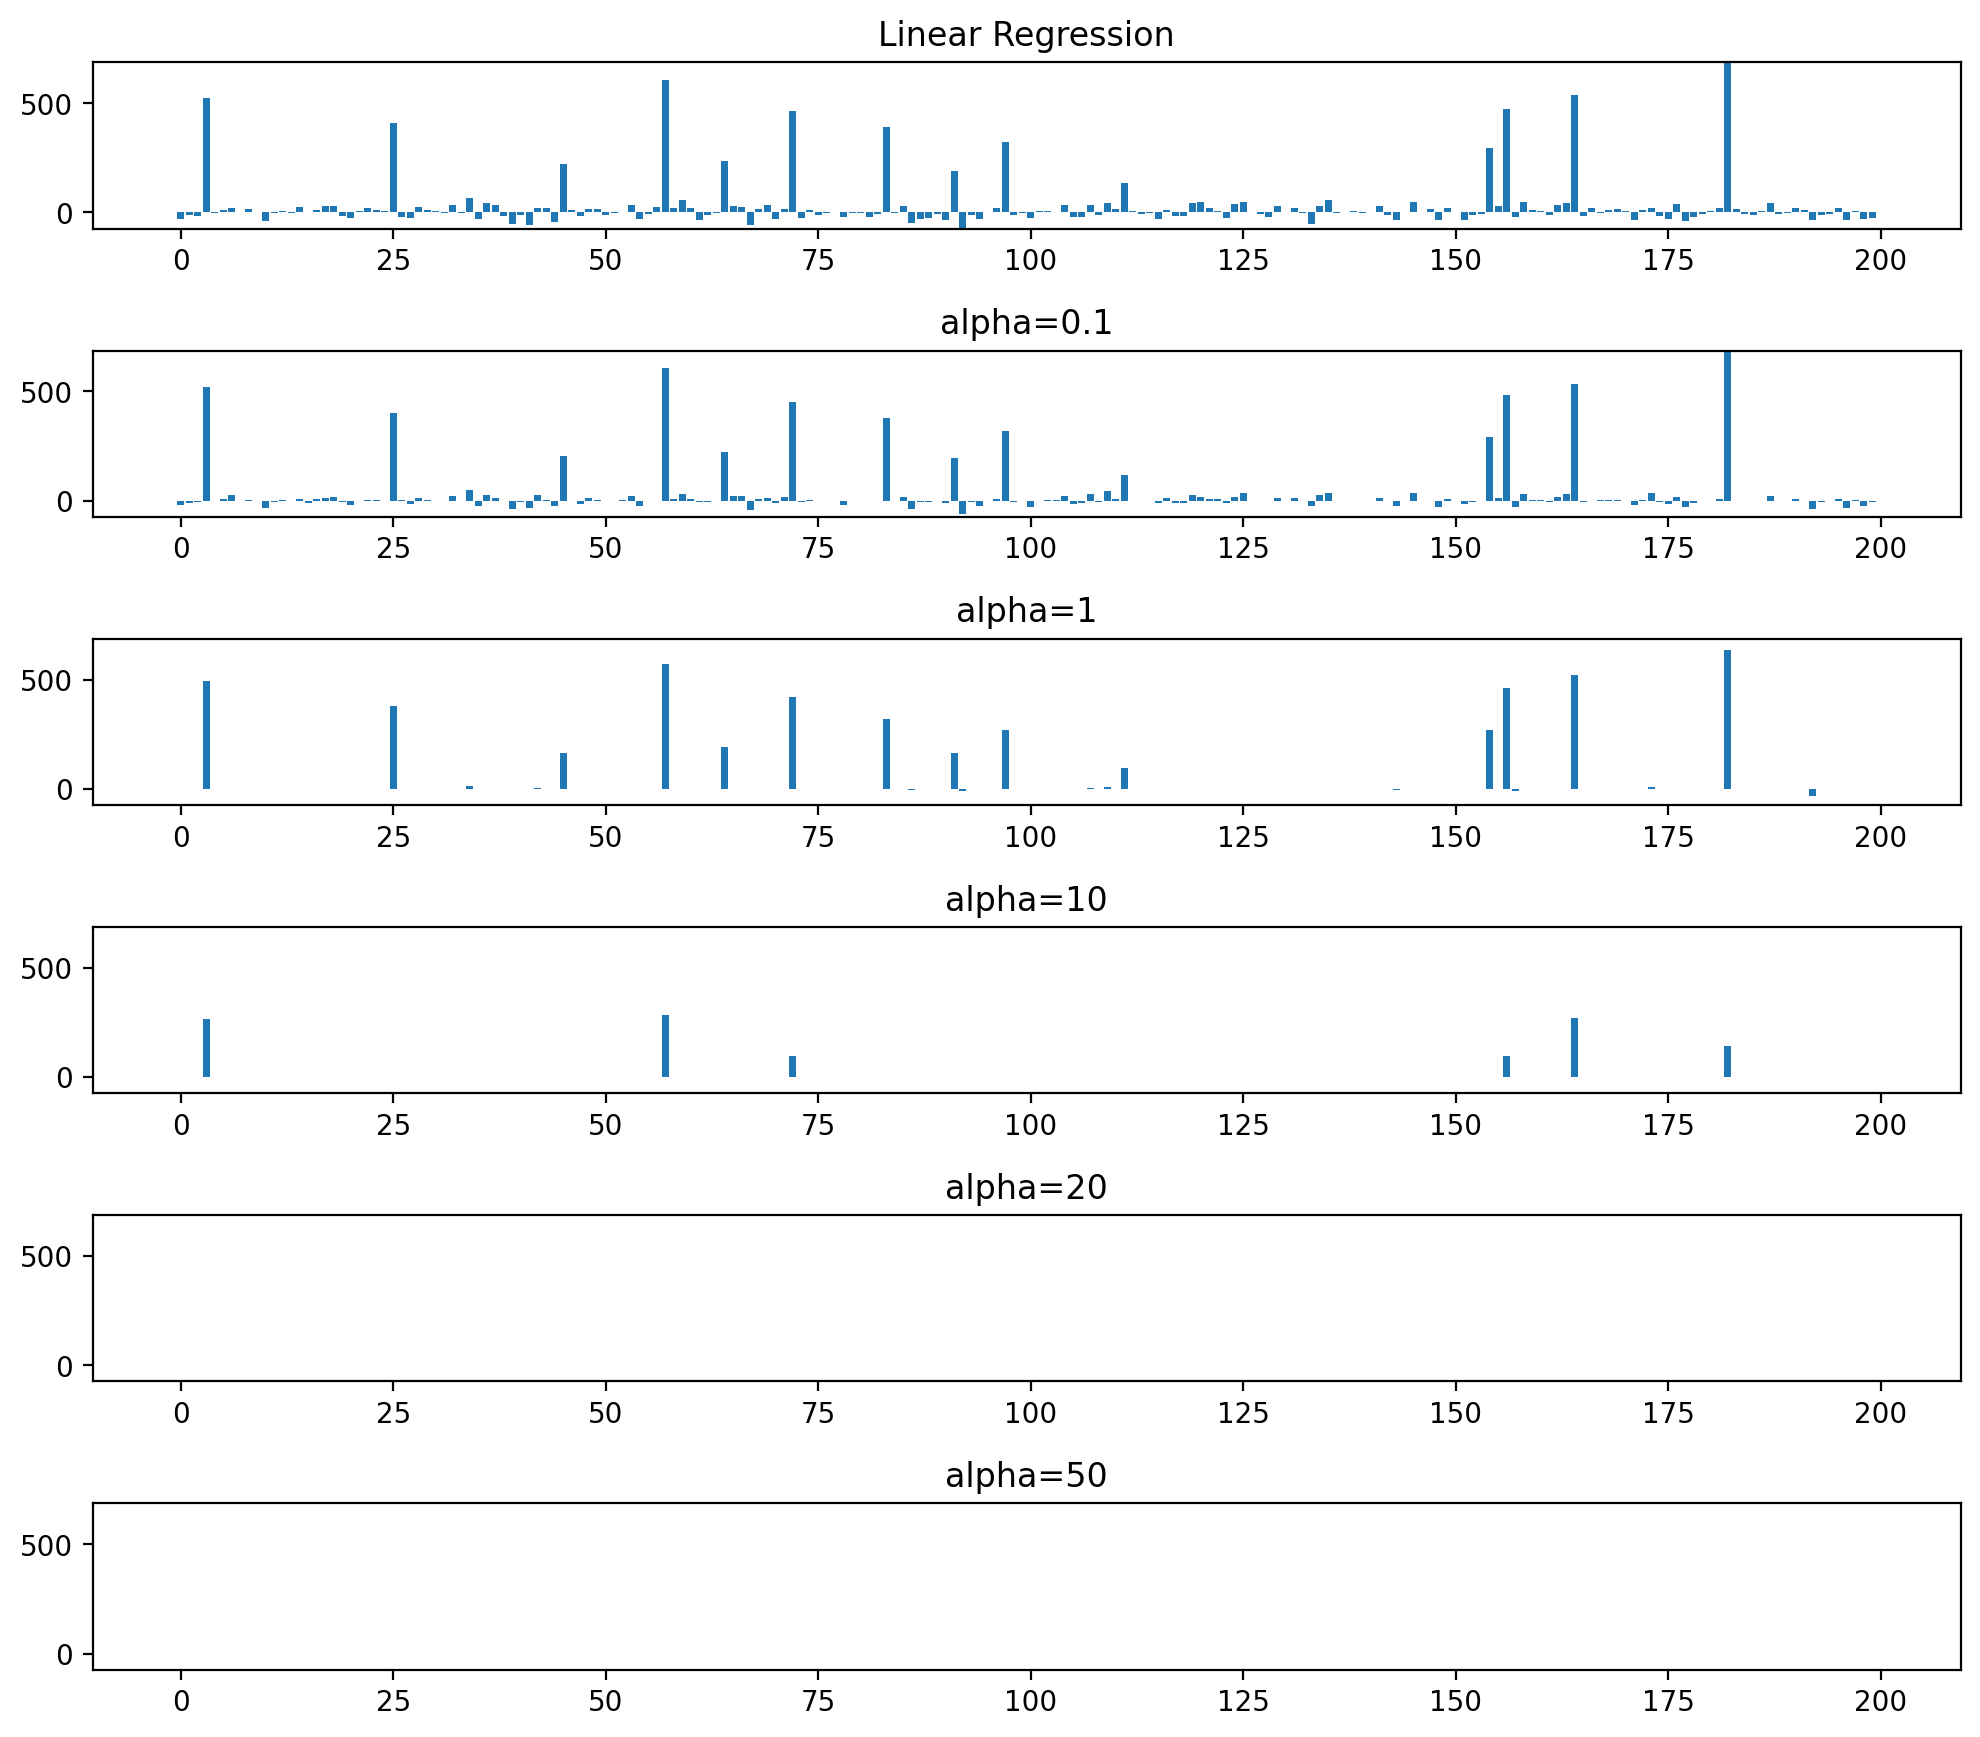

In [21]:
# y축 최솟값, 최댓값
y_min = model.coef_.min()
y_max = model.coef_.max()
alpha = [0.1, 1, 10, 20, 50]

# 회귀 계수 변화 시각화
plt.figure(figsize=(10,10))
plt.subplot(7,1,1)
plt.title('Linear Regression')
plt.bar(x=range(0, 200), height=model.coef_)
plt.ylim(y_min, y_max)

for idx, num in enumerate(alpha):
    plt.subplot(7,1,idx+2)
    plt.title(f'alpha={num}')
    plt.bar(x=range(0, 200), height=df_coef_ls.loc[num])
    plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

- LassoCV를 사용하면 주어진 범위 내에서 최선의 파라미터 값을 찾을 수 있다.

In [ ]:
from sklearn.linear_model import LassoCV

alpha = np.linspace(0.1, 100, 50) # 최소, 최대, 나누는값
model_ls = LassoCV(alphas=alpha, cv=5)
model_ls.fit(X_train, y_train)

# 성능 확인
print('학습성능:',  model_ls.score(X_train, y_train))
print('평가성능:',  model_ls.score(X_test, y_test))
print('-' * 28)
print('alpha:', model_ls.alpha_ )

학습성능: 0.9275849259507644
평가성능: 0.8872313036000192
----------------------------
alpha: 2.138775510204082


## 4.4.ElasticNet

- Elasticnet 알고리즘을 사용하면 Ridge와 Lasso 기능을 같이 사용할 수 있다.

$$ \large cost=\sum_{i=1}^{n}(y_i-\hat y)^2+\gamma\lambda\sum_{j=1}^{p}|w_j|+\frac{1-\gamma}{2}\lambda\sum_{j=1}^{p}(w_j)^2 $$

In [25]:
from sklearn.linear_model import ElasticNet

model_el = ElasticNet(alpha=0.01, l1_ratio=0.5)
model_el.fit(X_train, y_train)



print('평가 성능:',  model_el.score(X_train, y_train))
print('학습 성능:',  model_el.score(X_test, y_test))

평가 성능: 0.9516454956561059
학습 성능: 0.8007920620468021


- ElasticNetCV를 사용하면 주어진 범위 내에서 최선의 파라미터 값을 찾을 수 있다.

In [26]:
from sklearn.linear_model import ElasticNetCV

l1 = np.linspace(0.1,1,10)
alpha = np.linspace(0.1,10,50)
model_el = ElasticNetCV(l1_ratio=l1, alphas=alpha, cv=5)
model_el.fit(X_train, y_train)


# 성능 확인
print('학습성능:', model_el.score(X_train, y_train))
print('평가성능:', model_el.score(X_test, y_test))
print('-' * 28)
print('l1_ratio:', model_el.l1_ratio_)
print('alpha:', model_el.alpha_)

학습성능: 0.9615693809241096
평가성능: 0.9236929394694314
----------------------------
l1_ratio: 1.0
alpha: 0.7061224489795919


- 변수들의 가중치를 확인해 보면 모든 변수의 가중치가 줄었거나 제거됨을 알 수 있다.
- 본 예제에서는 Lasso와 같은 결과를 보여준다.

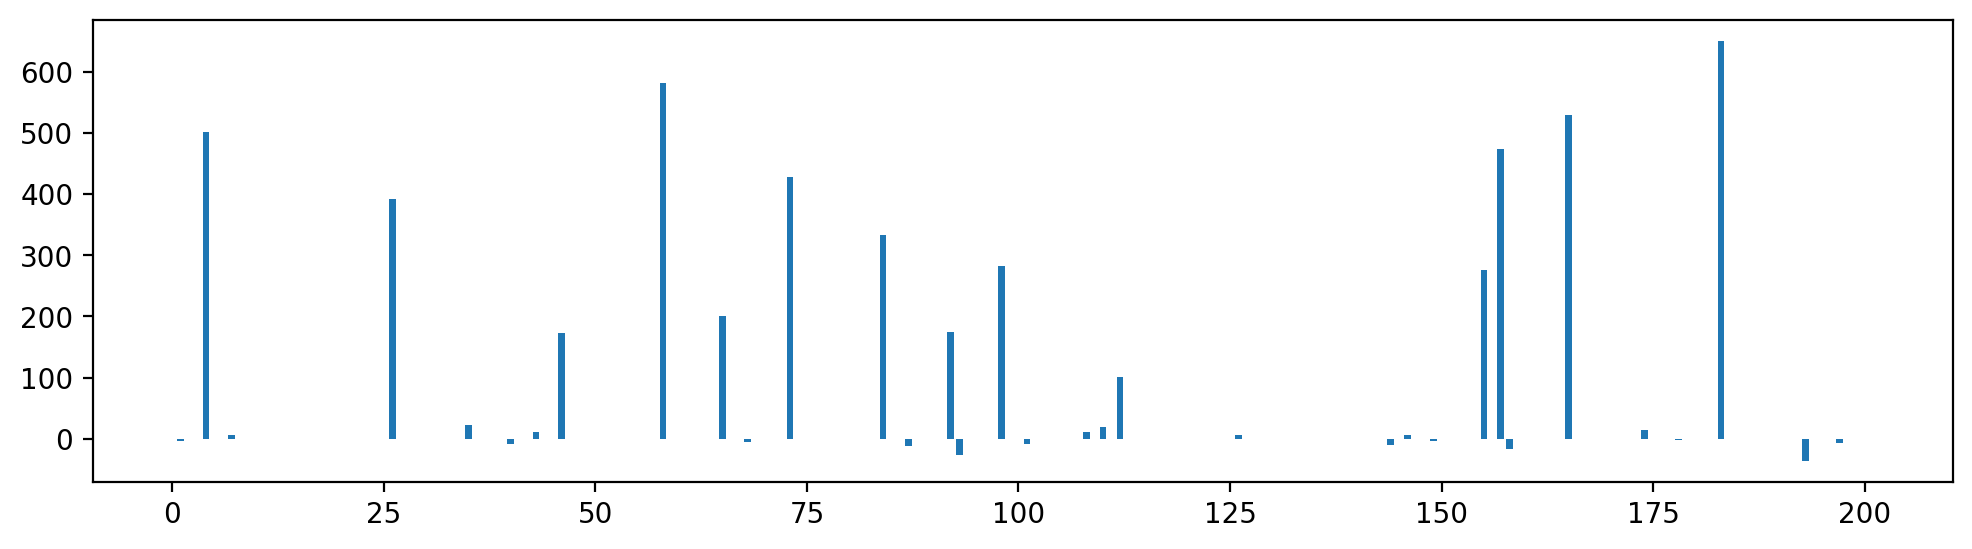

In [27]:
# 가중치 시각화
plt.figure(figsize=(12, 3))
plt.bar(x=range(1, 201), height=model_el.coef_)
plt.show()